In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("../data/processed/training_crime_data.csv")
print(df.shape)

(156, 47)


In [30]:
if 'crime_severity' not in df.columns:
    severity_map = {
        'MURDER' : 5,
        'RAPE': 5,
        'SHOOTING': 5,
        'ROBBERY': 4,
        'ACTS OF LASCIVIOUSNESS': 4,
        'CARNAPPING': 3,
        'MOTORNAPPING': 3,
        'PHYSICAL INJURIES': 3,
        'MAULING': 3,
        'THEFT': 1
    }
    df['crime_severity'] = df['offense'].str.upper().map(severity_map).fillna(2)

In [ ]:
def train_crime_penalty(df):
    features = [
        'lat', 'lng', 'month', 'day_of_week', 'hour', 'areaCrimeCount',
        'barangay_encoded', 'municipal_encoded', 'victimCount', 'crime_severity'
    ]

    X = df[features]
    y = df['crime_penalty']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_pred_train = model.predict(X_train)
    train_r2 = r2_score(y_train, y_pred_train)

    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"R^2: {r2_score(y_test, y_pred):.4f}")
    
    print(f"Training R2: {train_r2:.4f}")
    print(f"Test R2: {r2_score(y_test, y_pred):.4f}")

    if train_r2 - r2_score(y_test, y_pred) > 0.05:
        print("Possible overfitting")
    else:
        print("Model generalizes well")

    return model, X, features

In [43]:
df["crime_penalty"] = df["crime_penalty"].fillna(0)

In [44]:
model, X, features = train_crime_penalty(df)

MSE: 0.0007
R^2: 0.9926
Training R2: 0.9886
Test R2: 0.9926
Model generalizes well


In [35]:
print(df["crime_penalty"].isna().sum())

3


In [45]:
import matplotlib.pyplot as plt


Top Features:
             Feature  Importance
9     crime_severity    0.966816
8        victimCount    0.011325
6   barangay_encoded    0.008053
2              month    0.005711
0                lat    0.002899
5     areaCrimeCount    0.002767
1                lng    0.001766
3        day_of_week    0.000664
4               hour    0.000000
7  municipal_encoded    0.000000


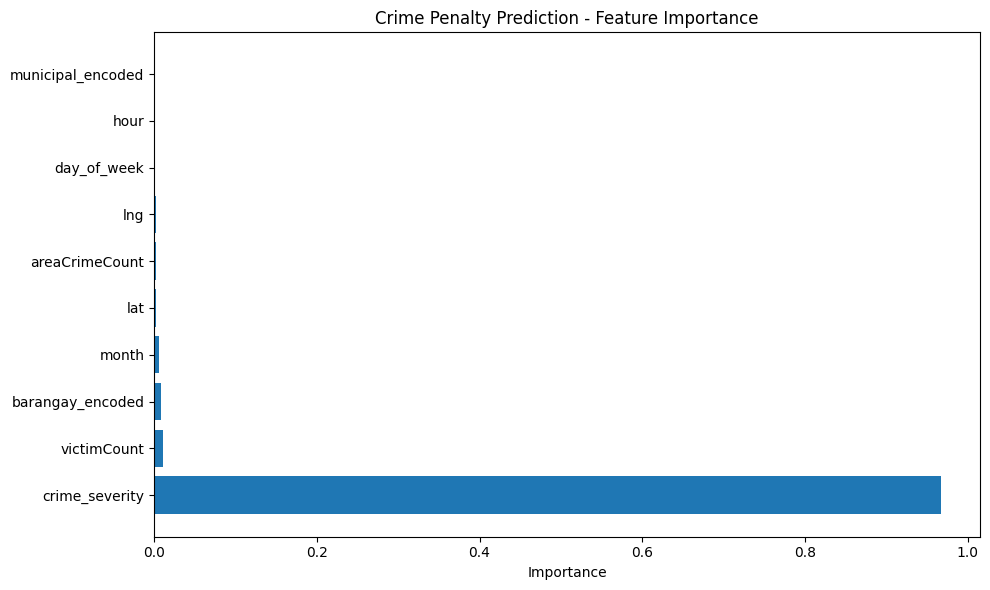

In [46]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'].head(10),feature_importance['Importance'].head(10))
plt.xlabel('Importance')
plt.title('Crime Penalty Prediction - Feature Importance')
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, df['crime_penalty'], cv=5, scoring='r2')
print(f"\nCross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f}")


Cross-validation R2 scores: [0.99991273 0.99821699 0.98237139 0.77397795 0.9141149 ]
Mean CV R2: 0.9337


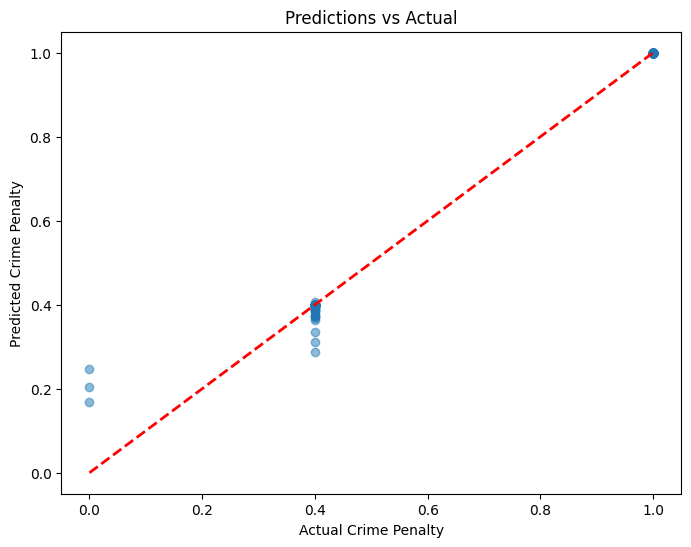

In [48]:
y_pred_all = model.predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(df['crime_penalty'], y_pred_all, alpha=0.5)
plt.plot([0,1],[0,1],'r--',lw=2)
plt.xlabel('Actual Crime Penalty')
plt.ylabel('Predicted Crime Penalty')
plt.title('Predictions vs Actual')
plt.show()

In [49]:
import pickle

with open('crime_penalty_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved: crime_penalty_model.pkl")

Model saved: crime_penalty_model.pkl
